In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(-0.001,), std=(1.001,))]) #was mean -0.5 and std 1.0 at round 1.

target_transform_one_hot_f = transforms.Lambda(lambda y: F.one_hot(torch.tensor(y), num_classes=10).float())

batch_size = 512

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=False, transform=transform,
                                        target_transform=target_transform_one_hot_f)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=False, transform=transform,
                                       target_transform=target_transform_one_hot_f)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

RuntimeError: Dataset not found. You can use download=True to download it

In [4]:
#for inputs, labels in trainloader:
#    inputs, labels = inputs.to(device), labels.to(device)

In [5]:
'''mask = (trainset.targets == 5) | (trainset.targets == 7)
trainset.data, trainset.targets = trainset.data[mask], trainset.targets[mask]
mask = (testset.targets  == 5) | (testset.targets  == 7)
#mask2 = (testset.targets == 9)
#altdata, alttargets = testset.data[mask2], testset.targets[mask2]
testset.data,  testset.targets  = testset.data[mask],  testset.targets[mask]'''

'mask = (trainset.targets == 5) | (trainset.targets == 7)\ntrainset.data, trainset.targets = trainset.data[mask], trainset.targets[mask]\nmask = (testset.targets  == 5) | (testset.targets  == 7)\n#mask2 = (testset.targets == 9)\n#altdata, alttargets = testset.data[mask2], testset.targets[mask2]\ntestset.data,  testset.targets  = testset.data[mask],  testset.targets[mask]'

In [6]:
#print(trainset.data.shape)
#print(testset.data.shape)

In [7]:
#trainset.data = trainset.data.reshape((trainset.data.shape[0],1,trainset.data.shape[1],trainset.data.shape[2])).float()
#testset.data = testset.data.reshape((testset.data.shape[0],1,testset.data.shape[1],testset.data.shape[2])).float()

#print(trainset.data.shape)
#print(testset.data.shape)

In [8]:
#trainset.targets = torch.subtract(trainset.targets, 5.0)/2
#testset.targets = torch.subtract(testset.targets, 5.0)/2

In [9]:
#trainset.targets

In [10]:
# define the CNN architecture

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        #self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc1 = nn.Linear(16 * 4 * 4, 128)
        #self.fc2 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(128, 64)
        #self.fc3 = nn.Linear(84, 10)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        #print(x.shape)
        x = self.pool(F.relu(self.conv2(x)))
        #print(x.shape)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x


#net = Net()

# move tensors to GPU if CUDA is available
#if train_on_gpu:
#    model.cuda()

In [11]:

# this shouldn't be needed here.
'''# here is the directional covariant derivative of an image.
def DirectionalCovariantDerivative(img,VF,Connection=None):
    # Create 1D arrays using linspace
    size = img.shape
    posX = size[0]//2
    posY = size[1]//2
    if size[0]%2==0:
        posX -= 0.5
        posY -= 0.5
    x_values = np.array([-posX+i for i in range(size[0])])
    #y_values = np.array([-posY+i for i in range(size[1])])
    y_values = np.array([posY-i for i in range(size[1])])

    #x_values = np.array([i for i in range(size[0])])
    #y_values = np.array([size[1]-i for i in range(size[1])])

    # Use meshgrid to create the 2D grid
    X, Y = np.meshgrid(x_values, y_values)
    # Stack the meshgrid arrays along a new axis
    points = np.stack((X, Y), axis=-1)

    # Reshape to get a matrix of coordinates
    matrix = points.reshape(-1, 2)


    VFatPts = torch.tensor(np.array([VF(p) for p in matrix])).float()
    #print(VFatPts.shape)
    VFatPts = VFatPts.reshape(size[0],size[1],2)

    imGrad=torch.stack(torch.gradient(img, dim=[1,0]))
    #imGrad = imGrad.reshape((3,size[0]*size[1],2))

    #out = torch.stack([imGrad[i]*VFatPts for i in range(3)])
    #out = torch.tensordot(VFatPts,imGrad,[[0,2],[2,0]])
    partials = torch.einsum('ijk,kijl->ijl',VFatPts.to(device),imGrad)
    if Connection==None:
        out=partials
    else:
        print("Connections are not yet supported. Returning the partial derivatives...")
        out=partials
    return out'''

'# here is the directional covariant derivative of an image.\ndef DirectionalCovariantDerivative(img,VF,Connection=None):\n    # Create 1D arrays using linspace\n    size = img.shape\n    posX = size[0]//2\n    posY = size[1]//2\n    if size[0]%2==0:\n        posX -= 0.5\n        posY -= 0.5\n    x_values = np.array([-posX+i for i in range(size[0])])\n    #y_values = np.array([-posY+i for i in range(size[1])])\n    y_values = np.array([posY-i for i in range(size[1])])\n\n    #x_values = np.array([i for i in range(size[0])])\n    #y_values = np.array([size[1]-i for i in range(size[1])])\n\n    # Use meshgrid to create the 2D grid\n    X, Y = np.meshgrid(x_values, y_values)\n    # Stack the meshgrid arrays along a new axis\n    points = np.stack((X, Y), axis=-1)\n\n    # Reshape to get a matrix of coordinates\n    matrix = points.reshape(-1, 2)\n\n\n    VFatPts = torch.tensor(np.array([VF(p) for p in matrix])).float()\n    #print(VFatPts.shape)\n    VFatPts = VFatPts.reshape(size[0],size

In [12]:
'''def DCDdata(X,VF,Connection=None):
    output = torch.stack([DirectionalCovariantDerivative(img,VF,Connection=Connection) for img in X])
    return output'''

'def DCDdata(X,VF,Connection=None):\n    output = torch.stack([DirectionalCovariantDerivative(img,VF,Connection=Connection) for img in X])\n    return output'

In [13]:
def SymTerm(model,X,VF,Connection=None):
    # This is the derivative of the model with respect to the images.
    X = X.requires_grad_(True)
    output = model(X)
    #print(output.shape)
    comp_funcs = torch.stack([VF(x) for x in X])
    grads = torch.stack([torch.mul(torch.autograd.grad( #this is a bit clunky. But we have to differentiate each component of the output.
        outputs=output[:,i],
        inputs=X,
        grad_outputs=torch.ones_like(output[:,i]),
        create_graph=True
    )[0],comp_funcs) for i in range(output.shape[1])])
    grads = torch.sum(grads, dim=2)
    #print(grads.shape)

    #return grads

    #self.comp_array = funcs
    #self.dim = np.shape(VF)[0]
    #print(torch.log(X[0][0]))
    #torch.stack([torch.log(x[0]) for x in X])
    #print(VF(X))


    #comp_funcs = torch.stack([VF(x) for x in X])
    #print(comp_funcs.shape)
    #comp_funcs = torch.transpose(comp_funcs,0,1)


    #X_f = torch.mul(comp_funcs, grads)
    #print(X_f.shape)
    return torch.transpose(grads,0,1) #X_f

    '''# Now we get the directional derivative of the images along the vector field.
    #grads = grads.to(device)
    dd = DCDdata(torch.transpose(X,1,3),VF,Connection=Connection) #.to(device) # this function could probably be adjusted so we don't have to take the transpose...
    #print(dd.shape)

    theans = torch.einsum('ltkji,lijk->ltij',torch.transpose(grads,0,1),dd)
    #print(theans.shape)
    return theans'''

In [14]:
model = Net()
#plVF = lambda x: np.array([np.log(x[0]),np.log(x[1]),np.log(x[2])])
#plVF = lambda x: np.array([np.log(x[0])])
plVF = lambda x: torch.log(x)
#rotVF = lambda x: np.array([-x[1]/np.sqrt(x[0]**2+x[1]**2),x[0]/np.sqrt(x[0]**2+x[1]**2)])
#model.load_state_dict(torch.load("rotVFmnist100Ssa", weights_only=True, map_location=torch.device('cpu')))

In [15]:
def vector_field_loss(y_pred, y_target, X_f, symmetry_loss_weight=0.5, criterion_model=nn.CrossEntropyLoss(), criterion_sym=nn.MSELoss()):
    model_loss = criterion_model
    #if symmetry_loss_weight==0:
    #    symmetry_loss = torch.tensor([0.0]) #100*criterion_sym(X_f, torch.zeros_like(X_f))
    #    total_loss = model_loss(y_pred, y_target)
    #else:
    symmetry_loss = 1*1*28*28*criterion_sym(X_f, torch.zeros_like(X_f))
    total_loss = (1.0 - symmetry_loss_weight) * model_loss(y_pred, y_target) + symmetry_loss_weight * symmetry_loss
    return total_loss, symmetry_loss

In [16]:
def train_with_symmetry(model, trainloader, VF, symmetry_loss_weight=0.5, optimizer=optim.Adam, nosymtime=0.5,
                        criterion_model=nn.CrossEntropyLoss(), criterion_sym=nn.MSELoss(), lr=1e-2, n_epochs=20, batchsize=None):
    #X_tensor = torch.tensor(X).float()
    #y_tensor = torch.tensor(y).float()
    #model = MLP(input_dim)
    optimizer = optimizer(model.parameters(), lr=lr) #optim.Adam(model.parameters(), lr=lr)
    sym_losses=[]

    for epoch in range(n_epochs):
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            #optimizer.zero_grad()
            if epoch < n_epochs*nosymtime:
                temp_symmetry_loss_weight = 0.0
            else:
                temp_symmetry_loss_weight = symmetry_loss_weight

            #if batchsize==None:
             #   batchsize=X.shape[0]

            #inds = np.random.randint(0, high=X.shape[0], size=batchsize)
            y_pred = model(inputs) #model(X[inds])
            #print(y_pred.shape)
            #print(y_pred)
            #print(labels.shape)
            #print(labels)
            #y_targets = y[inds]

            X_f = SymTerm(model,inputs,VF,Connection=None) #VF.apply(model, X) #compute_vector_field_loss(model, X_tensor)
            loss, sym_loss = vector_field_loss(y_pred, labels.reshape(y_pred.shape), X_f,
                                 symmetry_loss_weight=temp_symmetry_loss_weight, criterion_model=criterion_model, criterion_sym=criterion_sym)

            sym_losses += [sym_loss.item()]
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            if i % 50 == 0:
                print(f"Epoch [{epoch + 1}/{n_epochs}], minibatch [{i}], Loss: {loss.item():.6f}")
        if epoch % 1 == 0 or epoch == n_epochs - 1:
            print(f"Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.6f}")

    return model, sym_losses

In [17]:
model.to(device)
#trainset.data = trainset.data.to(device)
#trainset.targets = trainset.targets.to(device)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [18]:
print(device)

cpu


In [19]:
#train_with_symmetry(model, trainset.data, trainset.targets, rotVF, symmetry_loss_weight=0.5, criterion_model=nn.BCEWithLogitsLoss(), n_epochs=20,
#                    optimizer=moptim.rSGD, criterion_sym=nn.MSELoss(), lr=1e-3)

#result = train_with_symmetry(model, trainset.data, trainset.targets, rotVF, symmetry_loss_weight=0.9, criterion_model=nn.BCELoss(), n_epochs=200,
#                    optimizer=optim.Adam, criterion_sym=nn.MSELoss(), lr=1e-4, nosymtime=0.1, batchsize=1024)

result = train_with_symmetry(model, trainloader, plVF, symmetry_loss_weight=0.5, criterion_model=nn.CrossEntropyLoss(), n_epochs=4,
                    optimizer=optim.Adam, criterion_sym=nn.MSELoss(), lr=1e-3, nosymtime=1.0)

Epoch [1/4], minibatch [0], Loss: 2.303213
Epoch [1/4], minibatch [50], Loss: 1.777513
Epoch [1/4], minibatch [100], Loss: 1.704600
Epoch [1/4], Loss: 1.793408
Epoch [2/4], minibatch [0], Loss: 1.734362
Epoch [2/4], minibatch [50], Loss: 1.705859
Epoch [2/4], minibatch [100], Loss: 1.606254
Epoch [2/4], Loss: 1.523455
Epoch [3/4], minibatch [0], Loss: 1.547690
Epoch [3/4], minibatch [50], Loss: 1.520428
Epoch [3/4], minibatch [100], Loss: 1.519965
Epoch [3/4], Loss: 1.531289
Epoch [4/4], minibatch [0], Loss: 1.522130
Epoch [4/4], minibatch [50], Loss: 1.514239
Epoch [4/4], minibatch [100], Loss: 1.520694
Epoch [4/4], Loss: 1.502593


In [ ]:
torch.save(model.state_dict(), "noplVFmnist5-1")

In [ ]:
model.eval()

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

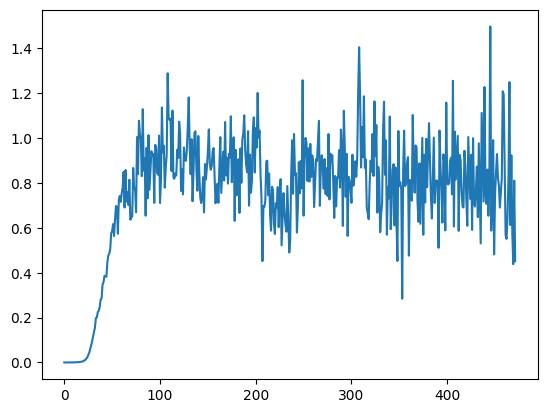

In [21]:
plt.plot(result[1])

In [ ]:
import csv

with open('noplsym_losses5.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    for row in result[1]:
        writer.writerow([row])

Text(0.5, 0, 'mini-batch number')

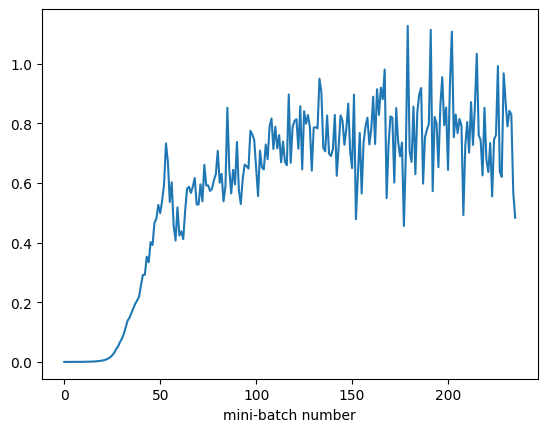

In [ ]:
plt.plot(result[1])
plt.xlabel("mini-batch number")


In [22]:
#testset.data = testset.data.to(device)
#testset.targets = testset.targets.to(device)

gammas = [0.1,0.2,0.25,0.33,0.5,1.0,1.5,1.66,1.75,1.8,1.9]
for j in gammas:

    rights = []
    for i, data in enumerate(testloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        #testRot = torchvision.transforms.functional.rotate(inputs,45*j)
        testRot = torchvision.transforms.functional.adjust_gamma(inputs, gamma=j, gain=1.0)
        preds = model(testRot)
        #print(labels)
        rPreds = torch.round(preds)
        #print(rPreds)

        rights += [1 for i in range(labels.shape[0]) if torch.min(labels[i]-rPreds[i]).item()==0.0]

    print(len(rights)/testset.data.shape[0])

    #y_pred = model(inputs) #model(X[inds])

0.4599
0.8956
0.9366
0.956
0.9616
0.9628
0.9621
0.9609
0.9608
0.9606
0.9602


In [ ]:
model2 = Net()
model2.load_state_dict(torch.load("rotVFmnist100Ssa", weights_only=True, map_location=torch.device('cpu')))

In [ ]:
testset.data.shape

(10000, 32, 32, 3)

In [ ]:
#preds = model(testset.data)
#rPreds = torch.tensor([np.round(preds[i].item()) for i in range(preds.shape[0])])
#rights = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds[i]]

for i in range(0,8):
    testRot = torchvision.transforms.functional.rotate(testset.data,45*i)
    preds = model(testRot)
    rPreds = torch.tensor([np.round(preds[i].item()) for i in range(preds.shape[0])])
    rights = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds[i]]
    print(len(rights)/testset.targets.shape[0])

'''testRot45 = torchvision.transforms.functional.rotate(testset.data,45)
testRot90 = torchvision.transforms.functional.rotate(testset.data,90)
testRot135 = torchvision.transforms.functional.rotate(testset.data,135)
testRot180 = torchvision.transforms.functional.rotate(testset.data,180)
testRot225 = torchvision.transforms.functional.rotate(testset.data,225)
testRot270 = torchvision.transforms.functional.rotate(testset.data,270)
testRot315 = torchvision.transforms.functional.rotate(testset.data,315)

preds45 = model(testRot45)
preds90 = model(testRot90)
preds135 = model(testRot135)
preds180 = model(testRot180)
preds225 = model(testRot225)
preds270 = model(testRot270)
preds315 = model(testRot315)

rPreds45 = torch.tensor([np.round(preds45[i].item()) for i in range(preds45.shape[0])])
rPreds90 = torch.tensor([np.round(preds90[i].item()) for i in range(preds90.shape[0])])
rPreds135 = torch.tensor([np.round(preds135[i].item()) for i in range(preds135.shape[0])])
rPreds180 = torch.tensor([np.round(preds180[i].item()) for i in range(preds180.shape[0])])
rPreds225 = torch.tensor([np.round(preds225[i].item()) for i in range(preds225.shape[0])])
rPreds270 = torch.tensor([np.round(preds270[i].item()) for i in range(preds270.shape[0])])
rPreds315 = torch.tensor([np.round(preds315[i].item()) for i in range(preds315.shape[0])])

rights45 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds45[i]]
rights90 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds90[i]]
rights135 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds135[i]]
rights180 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds180[i]]
rights225 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds225[i]]
rights270 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds270[i]]
rights315 = [1 for i in range(testset.targets.shape[0]) if testset.targets[i]==rPreds315[i]]

accs = [len(rights),len(rights45),len(rights90),len(rights135),len(rights180),len(rights225),len(rights270),len(rights315)]
accs = [x/testset.targets.shape[0] for x in accs]

plt.plot([0,45,90,135,180,225,270,315],accs)
plt.show()'''

TypeError: img should be PIL Image. Got <class 'numpy.ndarray'>

In [ ]:
#preds = model(trainset.data)
#rPreds = torch.tensor([np.round(preds[i].item()) for i in range(preds.shape[0])])
#rights = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds[i]]

#for i in range(0,8):
#    testRot = torchvision.transforms.functional.rotate(trainset.data,45*i)
#    preds = model(testRot)
#    rPreds = torch.tensor([np.round(preds[i].item()) for i in range(preds.shape[0])])
#    rights = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds[i]]
#    print(len(rights)/trainset.targets.shape[0])

'''testRot45 = torchvision.transforms.functional.rotate(trainset.data,45)
testRot90 = torchvision.transforms.functional.rotate(trainset.data,90)
testRot135 = torchvision.transforms.functional.rotate(trainset.data,135)
testRot180 = torchvision.transforms.functional.rotate(trainset.data,180)
testRot225 = torchvision.transforms.functional.rotate(trainset.data,225)
testRot270 = torchvision.transforms.functional.rotate(trainset.data,270)
testRot315 = torchvision.transforms.functional.rotate(trainset.data,315)

preds45 = model(testRot45)
preds90 = model(testRot90)
preds135 = model(testRot135)
preds180 = model(testRot180)
preds225 = model(testRot225)
preds270 = model(testRot270)
preds315 = model(testRot315)

rPreds45 = torch.tensor([np.round(preds45[i].item()) for i in range(preds45.shape[0])])
rPreds90 = torch.tensor([np.round(preds90[i].item()) for i in range(preds90.shape[0])])
rPreds135 = torch.tensor([np.round(preds135[i].item()) for i in range(preds135.shape[0])])
rPreds180 = torch.tensor([np.round(preds180[i].item()) for i in range(preds180.shape[0])])
rPreds225 = torch.tensor([np.round(preds225[i].item()) for i in range(preds225.shape[0])])
rPreds270 = torch.tensor([np.round(preds270[i].item()) for i in range(preds270.shape[0])])
rPreds315 = torch.tensor([np.round(preds315[i].item()) for i in range(preds315.shape[0])])

rights45 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds45[i]]
rights90 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds90[i]]
rights135 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds135[i]]
rights180 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds180[i]]
rights225 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds225[i]]
rights270 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds270[i]]
rights315 = [1 for i in range(trainset.targets.shape[0]) if trainset.targets[i]==rPreds315[i]]

accs = [len(rights),len(rights45),len(rights90),len(rights135),len(rights180),len(rights225),len(rights270),len(rights315)]
accs = [x/trainset.targets.shape[0] for x in accs]

plt.plot([0,45,90,135,180,225,270,315],accs)
plt.show()'''